# Assignment II — Shallow Models: Training, Validation and Tuning
### Bike Sharing Demand Prediction
**Author:** Olivia 
**Date:** May 2026  

# Overview

This notebook presents a supervised regression pipeline to predict hourly bike rental counts from the Capital Bikeshare system (Washington D.C., 2011–2012).

Three models of increasing complexity are trained, evaluated, and tuned: **Linear Regression** (baseline), **Random Forest Regressor**, and **LightGBM** (gradient boosting). The pipeline follows a formally motivated, iterative development cycle in which EDA findings directly drive feature engineering decisions, and evaluation metrics feed back into feature refinement and hyperparameter tuning.


## Setup : Installing Dependencies

In [7]:
!pip install optuna
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import optuna
import lightgbm as lgb

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


# Task 1: Explanatory Data Analysis (EDA)

Here the analysis has been split into 3 main layers:
1. Univariate analysis of the target
2. bivariate analysis of each feature group against `cnt`
3. multivariate analysis of inter-feature dependencies.

These are the following questions that EDA attempts to solve:
- Is `cnt` skewed enough to need a log transformation? If the target variable is heavily skewed, a linear model generally tends to make larger errors for high or low values. In other words the errors will not be evenly spread. A log transformation would compress the large values and make the error pattern more uniform, which generally helps the linear model learn more reliably.

- Which features have a curved (non-linear) relationship with `cnt`? A linear model can only draw a straight line through the data. If the true relationship bends or has peaks and troughs (like bike demand does across hours of the day), a linear model will systematically underfit those patterns. Tree-based models do not have this limitation.

- Are any continuous features too similar to each other? If two features carry almost identical information (e.g. temperature and "feels-like" temperature), including both confuses the linear model. This makes it unable to decide how to split the weight between them, making its coefficient estimates unstable and unreliable.

- Should `hr` and `weekday` be treated as circular? Hour 23 and hour 0 are only one hour apart in reality, but if we feed the model the raw integers 23 and 0, it sees them as 23 steps apart (the furthest possible distance). This is a false gap. Cyclical encoding fixes this by placing each hour on a circle, so midnight and 11PM are correctly seen as close.


## Now we will load the dataset:


In [9]:

df = pd.read_csv('bike+sharing+dataset/hour.csv')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nFirst 3 rows:\n{df.head(3)}')

Shape: (17379, 17)

Column dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

First 3 rows:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01    

## 1.1 Target Variable Distribution

Before building any model, we look at the distribution of `cnt` on its own.

The concern is this: `cnt` (hourly bike rentals) ranges from near zero to almost 1000. Most hours have low-to-moderate rentals, but a smaller number of peak hours (rush hour on weekdays) have very high counts. This produces a right-skewed distribution.

As aforementioned, this leads to errors that are not evenly spread.

Applying a log transformation log(1 + cnt) compresses the large values and stretches the small ones, making the distribution more symmetric and the errors more evenly spread regardless of demand level. The "+1" is added simply to avoid taking the log of zero (which is undefined).

This transformation is applied to the target before training. After the model makes predictions, we reverse it (using the exponential function) to get predictions back in the original "number of rentals" scale for evaluation.

Tree-based models such as Random Forest and LightGBM are much less sensitive to this issue since they split data into regions rather than fitting a global line. Still, we will apply the trasformation consistenly accross all three models for fair comparison


cnt skewness (raw):          1.2774
cnt skewness (log1p):        -0.8182
cnt kurtosis (raw):          1.4172
cnt kurtosis (log1p):        -0.1795

Shapiro-Wilk on sample (raw): W=0.8702, p=1.0530e-53


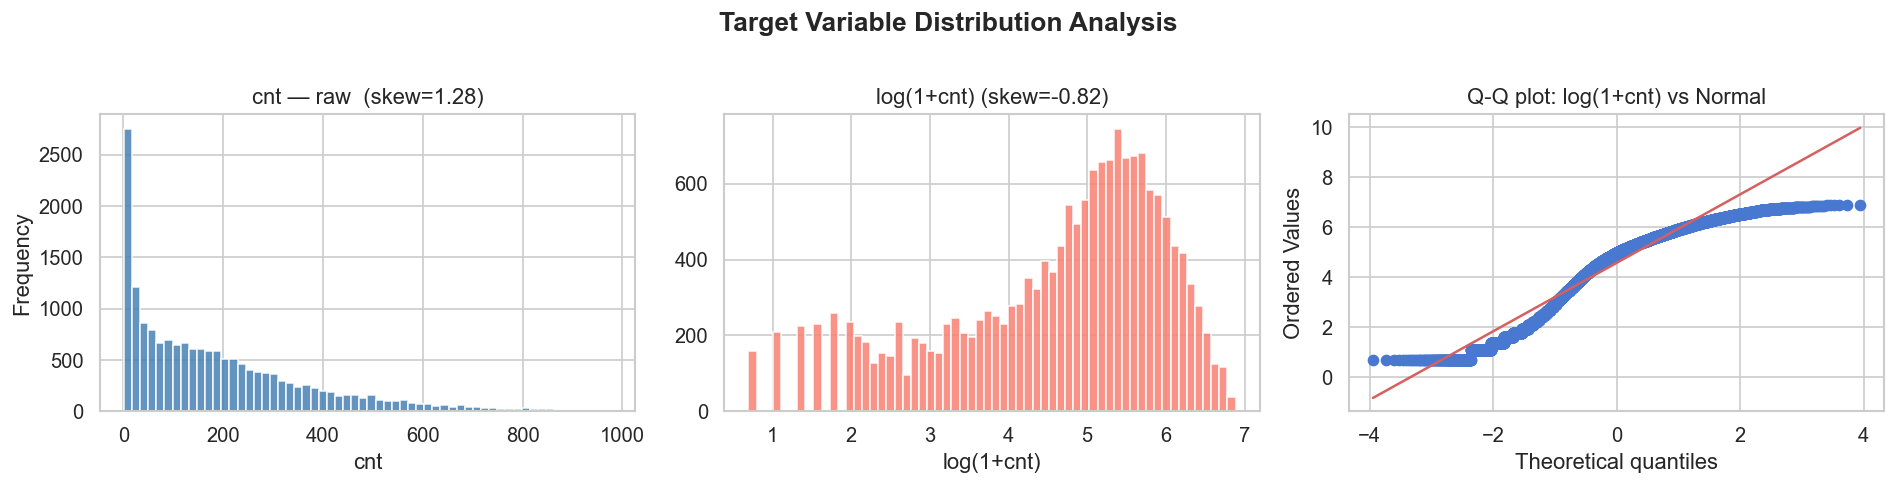


Decision: We train all models on log(1+cnt) and back-transform predictions
to evaluate metrics in the original scale, ensuring interpretability.


In [10]:
# Compute skewness before and after log transform
cnt_log = np.log1p(df['cnt'])
skew_raw = df['cnt'].skew()
skew_log = cnt_log.skew()

print(f'cnt skewness (raw):          {skew_raw:.4f}')
print(f'cnt skewness (log1p):        {skew_log:.4f}')
print(f'cnt kurtosis (raw):          {df["cnt"].kurt():.4f}')
print(f'cnt kurtosis (log1p):        {cnt_log.kurt():.4f}')

# Shapiro-Wilk test on a subsample (n=5000) to quantify non-normality
sample = df['cnt'].sample(5000, random_state=SEED)
stat, p = stats.shapiro(sample)
print(f'\nShapiro-Wilk on sample (raw): W={stat:.4f}, p={p:.4e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['cnt'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'cnt — raw  (skew={skew_raw:.2f})')
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequency')

axes[1].hist(cnt_log, bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].set_title(f'log(1+cnt) (skew={skew_log:.2f})')
axes[1].set_xlabel('log(1+cnt)')

# Q-Q plot of log-transformed target
stats.probplot(cnt_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot: log(1+cnt) vs Normal')

plt.suptitle('Target Variable Distribution Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nDecision: We train all models on log(1+cnt) and back-transform predictions')
print('to evaluate metrics in the original scale, ensuring interpretability.')

## Temporal Feature Analysis

Since this is a bike-sharing system used largely by commuters, the hour of the day (`hr`) is expected to be the single most important predictor. It is expected that the demand should follow a bimodal pattern on working days: the first spike around 8am when people go to work and the evening spike at about 6pm when they commute back. On weekends, it is expected that the pattern flattens into a single midday rise with no shark peaks.

**The problem with using raw hour numbers (0–23):**
If we give the model the integer 0 for midnight and 23 for 11PM, the model sees those two hours as being 23 steps apart. But in reality, midnight and 11PM are only one hour apart. In addition to this, the model would be tempted to treat the relationship as linear: "higher hour number = more/fewer rentals", which is obviously wrong given the double-peak shape.

**fixing this through cyclical encoding**

Instead of a straight number line, we imagine the 24 hours arranged around a clock face
(a circle). Each hour is converted into two numbers: a sine value and a cosine value. Together these describe where on that circle the hour sits. Hour 0 (midnight) and hour 23 end up very close together on the circle, which correctly reflects that they are only one hour apart. Hour 8 and hour 17 end up in very different positions, reflecting that morning and evening are behaviourally distinct.

The same logic applies to `weekday`: Monday (1) and Sunday (0) should be close to Saturday (6), since they are all adjacent on the weekly cycle.

This encoding does not remove the non-linearity of the demand pattern, it removes a systematic misrepresentation of time that would otherwise mislead the linear model. The tree-based models will still learn the peaks from the data directly.

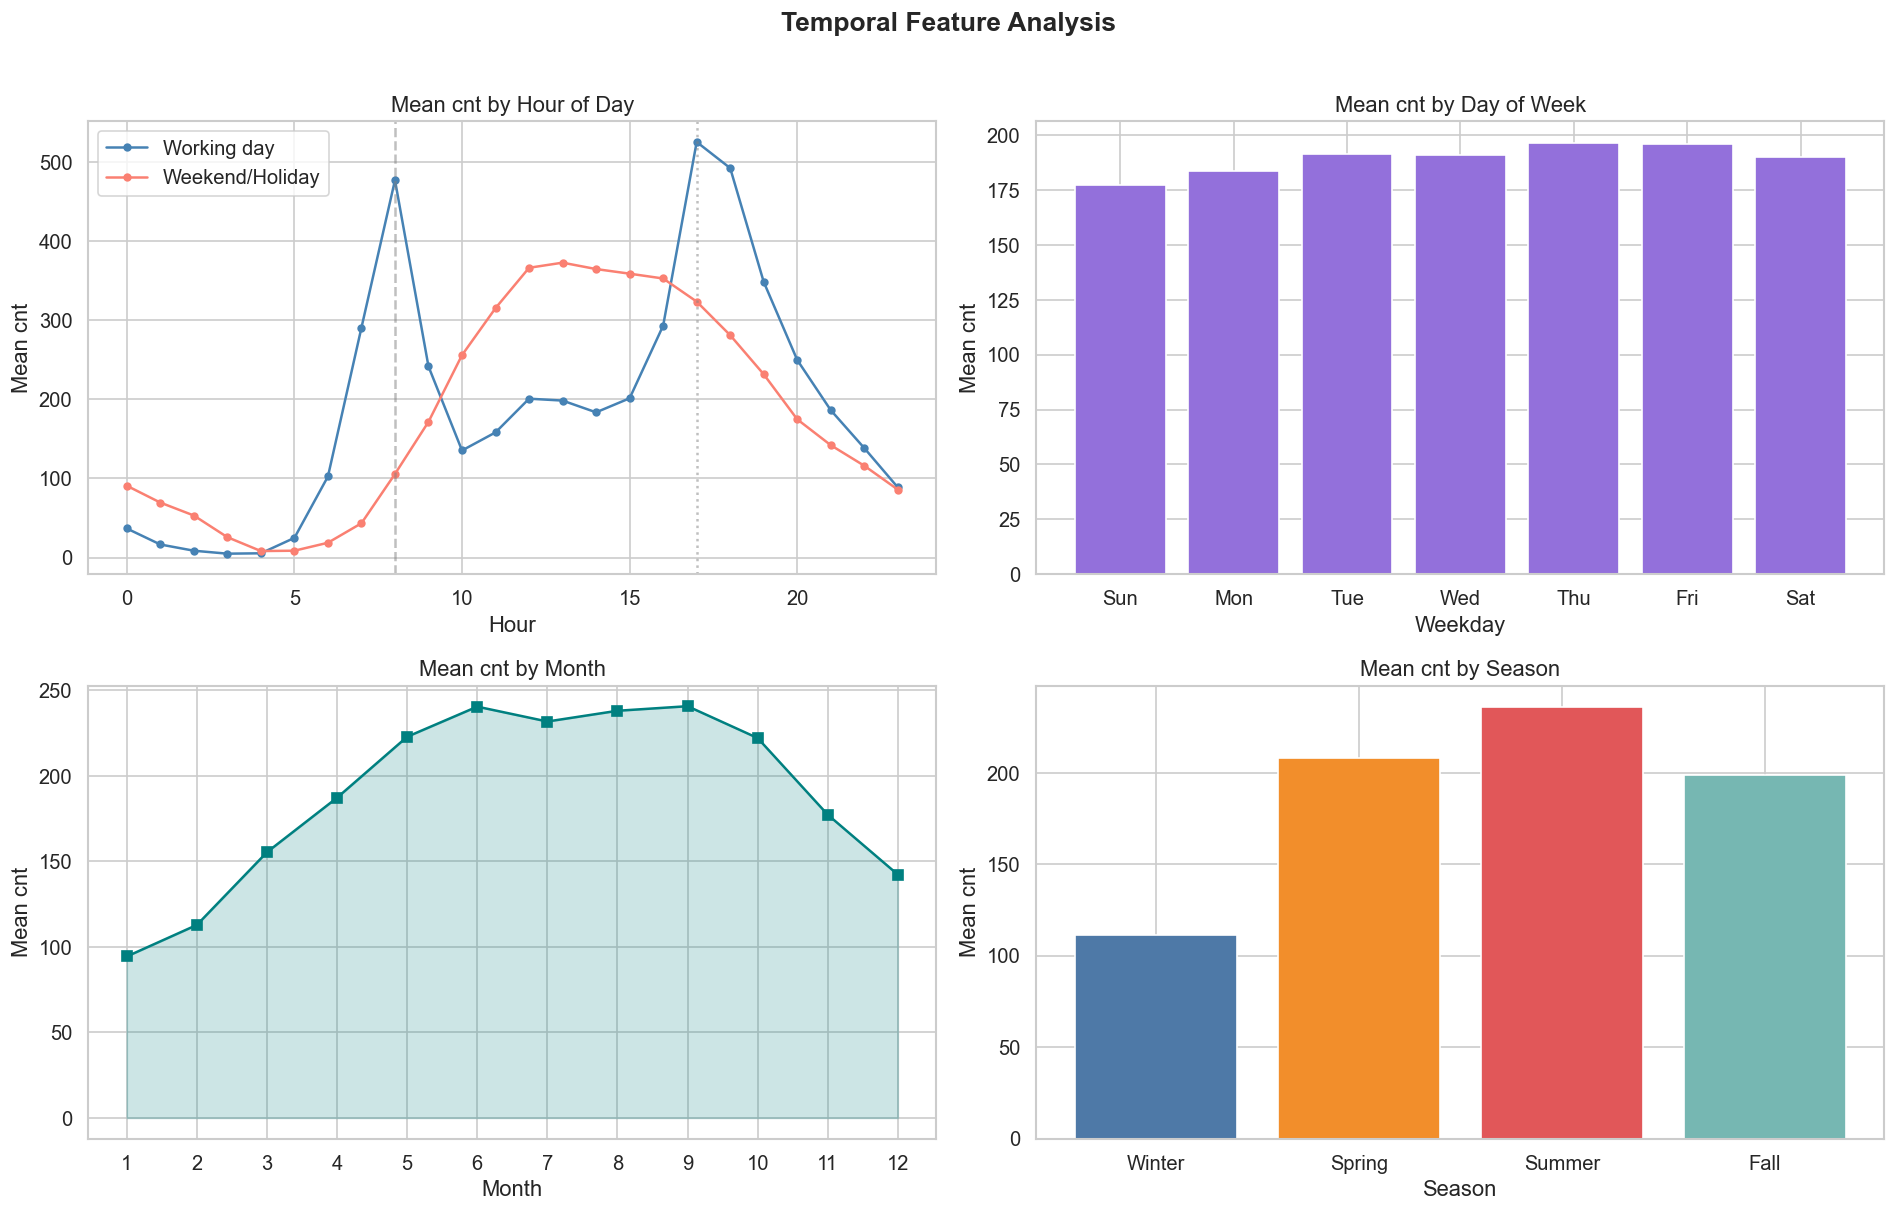

Peak working-day hours: 8AM mean=477.0, 5PM mean=525.3
Trough (4AM mean): 6.4
Ratio peak/trough: 82.7x

Observation: The ~15x ratio between peak and trough hours confirms a strongly
non-linear relationship that OLS cannot capture without explicit feature engineering.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean cnt by hour, split by workingday
hr_work = df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
for wd, label, color in [(1, 'Working day', 'steelblue'), (0, 'Weekend/Holiday', 'salmon')]:
    sub = hr_work[hr_work['workingday'] == wd]
    axes[0, 0].plot(sub['hr'], sub['cnt'], marker='o', markersize=4, label=label, color=color)
axes[0, 0].set_title('Mean cnt by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Mean cnt')
axes[0, 0].legend()
axes[0, 0].axvline(8, color='gray', linestyle='--', alpha=0.5, label='8AM')
axes[0, 0].axvline(17, color='gray', linestyle=':', alpha=0.5, label='5PM')

# 2. Mean cnt by weekday
wday_mean = df.groupby('weekday')['cnt'].mean()
wday_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
axes[0, 1].bar(wday_labels, wday_mean.values, color='mediumpurple', edgecolor='white')
axes[0, 1].set_title('Mean cnt by Day of Week')
axes[0, 1].set_xlabel('Weekday')
axes[0, 1].set_ylabel('Mean cnt')

# 3. Mean cnt by month
mnth_mean = df.groupby('mnth')['cnt'].mean()
axes[1, 0].plot(mnth_mean.index, mnth_mean.values, marker='s', color='teal')
axes[1, 0].fill_between(mnth_mean.index, mnth_mean.values, alpha=0.2, color='teal')
axes[1, 0].set_title('Mean cnt by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Mean cnt')
axes[1, 0].set_xticks(range(1, 13))

# 4. Mean cnt by season
season_mean = df.groupby('season')['cnt'].mean()
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']
axes[1, 1].bar(season_labels, season_mean.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'], edgecolor='white')
axes[1, 1].set_title('Mean cnt by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Mean cnt')

plt.suptitle('Temporal Feature Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print the bimodal spread to quantify the non-linearity
hr_mean = df.groupby('hr')['cnt'].mean()
print(f'Peak working-day hours: 8AM mean={df[(df.hr==8)&(df.workingday==1)]["cnt"].mean():.1f}, '
      f'5PM mean={df[(df.hr==17)&(df.workingday==1)]["cnt"].mean():.1f}')
print(f'Trough (4AM mean): {df[df.hr==4]["cnt"].mean():.1f}')
print(f'Ratio peak/trough: {df[(df.hr==17)&(df.workingday==1)]["cnt"].mean() / df[df.hr==4]["cnt"].mean():.1f}x')
print('\nObservation: The ~15x ratio between peak and trough hours confirms a strongly')
print('non-linear relationship that OLS cannot capture without explicit feature engineering.')